In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [70]:
df_before_spliting=pd.read_csv("./ssm_all_features_new_data_new_label.csv")

In [71]:
df_before_spliting

,0,1,2,3,4,5,6,7,8,9,...,state_input_distance,long_term_state_drift,state_similarity,state_input_similarity,long_term_state_similarity,mean_squared_change_short,mean_squared_change_long,conv_id,turn_id,y
0,0.022156,0.009600,-0.005651,0.037142,0.026982,0.014868,-0.013620,-0.011513,0.020963,-0.005187,...,1.086266,0.000000,0.000000,0.025019,1.000000,0.000264,0.000000,0.0,0.0,0
1,0.033551,0.014626,-0.013005,0.029625,0.038335,-0.000664,-0.020039,-0.016444,0.017359,0.001949,...,1.108700,0.298725,0.789470,-0.009810,0.789470,0.000116,0.000116,0.0,1.0,0
2,0.028587,0.021823,-0.007307,0.023240,0.034987,-0.015518,-0.027399,-0.020127,0.009395,-0.001386,...,1.104958,0.361161,0.889950,-0.016561,0.680631,0.000061,0.000170,0.0,2.0,0
3,0.014920,0.008290,-0.004189,0.028177,0.026437,-0.005988,-0.020008,-0.018204,0.015614,0.006017,...,1.087798,0.348555,0.925097,-0.007144,0.681603,0.000039,0.000158,0.0,3.0,0
4,0.018797,0.009575,0.000537,0.024246,0.037969,-0.012389,-0.027038,-0.023365,0.010820,0.000679,...,1.075004,0.368452,0.914687,0.042450,0.656864,0.000042,0.000177,0.0,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14379,-0.039515,-0.010074,0.023661,0.012855,0.003421,-0.014791,-0.001751,-0.013007,-0.003218,0.023564,...,1.114362,0.000000,0.000000,-0.046897,1.000000,0.000260,0.000000,3036.0,0.0,0
14380,-0.025135,-0.037671,0.049991,0.015364,0.017914,-0.003555,-0.016524,-0.040135,0.000613,0.039743,...,1.314381,0.591394,0.730425,-0.020215,0.730425,0.000455,0.000455,3036.0,1.0,0
14381,-0.045876,-0.045405,0.060885,0.009341,0.021263,-0.006970,-0.020927,-0.049787,-0.003796,0.040816,...,1.463796,0.823468,0.922363,-0.031985,0.644762,0.000229,0.000883,3036.0,2.0,0
14382,-0.025517,-0.023269,0.039099,-0.018240,0.013294,-0.007832,-0.033553,-0.047526,-0.006112,0.039862,...,1.262010,0.564850,0.834031,-0.031804,0.645718,0.000447,0.000415,3036.0,3.0,0


In [72]:
TRAIN_PATH = "./train.csv"
VALIDATION_PATH = "./validation.csv"
TEST_PATH = "./test.csv"

In [73]:
tca_train_df= pd.read_csv(TRAIN_PATH)
tca_validation_df= pd.read_csv(VALIDATION_PATH)
tca_test_df= pd.read_csv(TEST_PATH)

In [74]:
j1=pd.merge(tca_train_df, tca_test_df, on=["conv_id","turn_id"], how='inner')
j2=pd.merge(tca_train_df, tca_validation_df, on=["conv_id","turn_id"], how='inner')
j3=pd.merge(tca_validation_df, tca_test_df, on=["conv_id","turn_id"], how='inner')

assert len(j1) == 0
assert len(j2) == 0
assert len(j3) == 0

In [75]:
train_df = pd.merge(tca_train_df, df_before_spliting, on=["conv_id","turn_id"], how='inner')
validation_df = pd.merge(tca_validation_df, df_before_spliting, on=["conv_id","turn_id"], how='inner')
test_df = pd.merge(tca_test_df, df_before_spliting, on=["conv_id","turn_id"], how='inner')

In [76]:
columns_to_drop = set(tca_train_df.columns).difference(["conv_id", "turn_id"])

In [77]:
df_all=train_df.drop(columns=columns_to_drop)
df_validation=validation_df.drop(columns=columns_to_drop)
df_test=test_df.drop(columns=columns_to_drop)

In [78]:
df_all

,conv_id,turn_id,0,1,2,3,4,5,6,7,...,1535,state_drift,state_input_distance,long_term_state_drift,state_similarity,state_input_similarity,long_term_state_similarity,mean_squared_change_short,mean_squared_change_long,y
0,0,0,0.022156,0.009600,-0.005651,0.037142,0.026982,0.014868,-0.013620,-0.011513,...,-0.020168,0.449988,1.086266,0.000000,0.000000,0.025019,1.000000,0.000264,0.000000,0
1,0,1,0.033551,0.014626,-0.013005,0.029625,0.038335,-0.000664,-0.020039,-0.016444,...,0.016277,0.298725,1.108700,0.298725,0.789470,-0.009810,0.789470,0.000116,0.000116,0
2,0,2,0.028587,0.021823,-0.007307,0.023240,0.034987,-0.015518,-0.027399,-0.020127,...,0.000744,0.216980,1.104958,0.361161,0.889950,-0.016561,0.680631,0.000061,0.000170,0
3,0,3,0.014920,0.008290,-0.004189,0.028177,0.026437,-0.005988,-0.020008,-0.018204,...,-0.005025,0.172313,1.087798,0.348555,0.925097,-0.007144,0.681603,0.000039,0.000158,0
4,0,4,0.018797,0.009575,0.000537,0.024246,0.037969,-0.012389,-0.027038,-0.023365,...,-0.002960,0.178567,1.075004,0.368452,0.914687,0.042450,0.656864,0.000042,0.000177,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8663,3034,0,-0.006587,0.012588,-0.010828,0.010226,0.002456,-0.013477,-0.009957,0.009681,...,0.012283,0.463975,1.082943,0.000000,0.000000,0.045808,1.000000,0.000280,0.000000,0
8664,3034,1,-0.041395,0.020188,-0.002852,-0.013824,-0.002849,-0.028310,0.022127,0.008046,...,-0.044293,0.450296,1.183252,0.450296,0.726804,0.022435,0.726804,0.000264,0.000264,0
8665,3034,2,-0.034212,0.020935,-0.016976,-0.004691,0.012364,-0.027081,0.023507,-0.002327,...,0.001410,0.265697,1.186717,0.437556,0.918230,0.019304,0.748686,0.000092,0.000249,0
8666,3034,3,-0.029566,0.013197,-0.005921,-0.022461,-0.001375,-0.012869,0.023883,0.000250,...,-0.010973,0.415985,1.316302,0.699213,0.893113,0.023926,0.613554,0.000225,0.000637,0


In [79]:
df_all.head()

,conv_id,turn_id,0,1,2,3,4,5,6,7,...,1535,state_drift,state_input_distance,long_term_state_drift,state_similarity,state_input_similarity,long_term_state_similarity,mean_squared_change_short,mean_squared_change_long,y
0,0,0,0.022156,0.009600,-0.005651,0.037142,0.026982,0.014868,-0.013620,-0.011513,...,-0.020168,0.449988,1.086266,0.000000,0.000000,0.025019,1.000000,0.000264,0.000000,0
1,0,1,0.033551,0.014626,-0.013005,0.029625,0.038335,-0.000664,-0.020039,-0.016444,...,0.016277,0.298725,1.108700,0.298725,0.789470,-0.009810,0.789470,0.000116,0.000116,0
2,0,2,0.028587,0.021823,-0.007307,0.023240,0.034987,-0.015518,-0.027399,-0.020127,...,0.000744,0.216980,1.104958,0.361161,0.889950,-0.016561,0.680631,0.000061,0.000170,0
3,0,3,0.014920,0.008290,-0.004189,0.028177,0.026437,-0.005988,-0.020008,-0.018204,...,-0.005025,0.172313,1.087798,0.348555,0.925097,-0.007144,0.681603,0.000039,0.000158,0
4,0,4,0.018797,0.009575,0.000537,0.024246,0.037969,-0.012389,-0.027038,-0.023365,...,-0.002960,0.178567,1.075004,0.368452,0.914687,0.042450,0.656864,0.000042,0.000177,0


In [92]:
vector_list= list(str(col) for col in range(768+768))
vector_list.append("conv_id")
vector_list.append("turn_id")
vector_list.append("y")
features_list = list(set(df_all.columns.tolist()).difference(set(vector_list)))
features_list.append("y")

In [93]:
df_vectors = df_before_spliting[vector_list]

In [82]:
df = df_all[features_list]

In [ ]:
df["label"]=df["y"]
df.drop(columns=["y"], inplace=True)

In [84]:
df 

,state_similarity,mean_squared_change_short,state_input_similarity,long_term_state_similarity,state_input_distance,long_term_state_drift,mean_squared_change_long,state_drift,label
0,0.000000,0.000264,0.025019,1.000000,1.086266,0.000000,0.000000,0.449988,0
1,0.789470,0.000116,-0.009810,0.789470,1.108700,0.298725,0.000116,0.298725,0
2,0.889950,0.000061,-0.016561,0.680631,1.104958,0.361161,0.000170,0.216980,0
3,0.925097,0.000039,-0.007144,0.681603,1.087798,0.348555,0.000158,0.172313,0
4,0.914687,0.000042,0.042450,0.656864,1.075004,0.368452,0.000177,0.178567,0
...,...,...,...,...,...,...,...,...,...
8663,0.000000,0.000280,0.045808,1.000000,1.082943,0.000000,0.000000,0.463975,0
8664,0.726804,0.000264,0.022435,0.726804,1.183252,0.450296,0.000264,0.450296,0
8665,0.918230,0.000092,0.019304,0.748686,1.186717,0.437556,0.000249,0.265697,0
8666,0.893113,0.000225,0.023926,0.613554,1.316302,0.699213,0.000637,0.415985,0


In [25]:
feature_names=df.columns.tolist()
unique_labels = df["label"].unique()

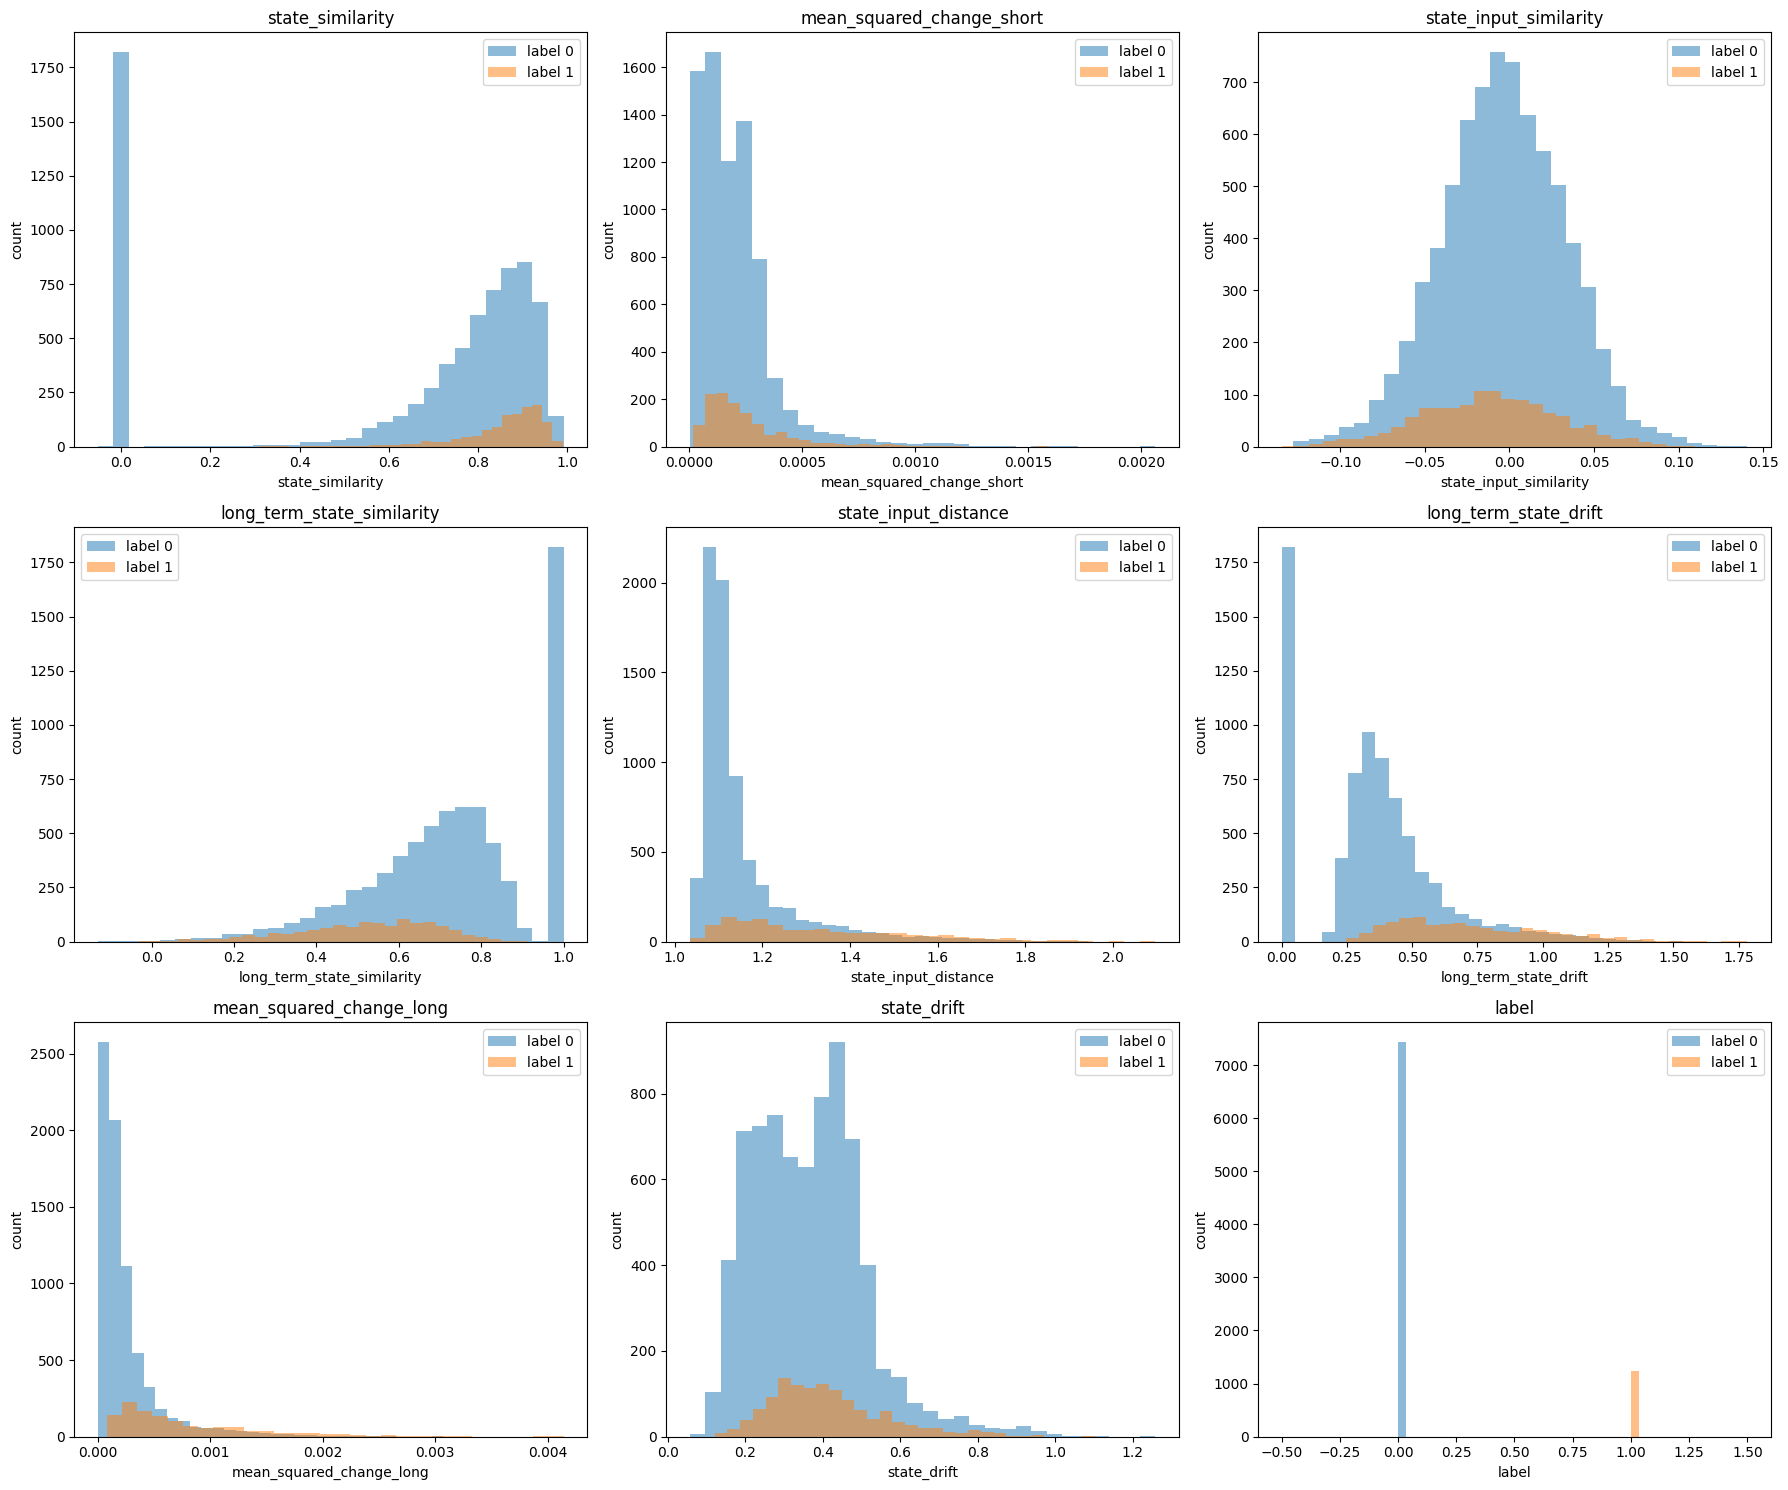

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(feature_names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 15)) # create subplots
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    ax = axes[i]
    for lbl in unique_labels:
        subset = df[df["label"] == lbl][feature] # gets feature with this label
        ax.hist(subset, bins=30, alpha=0.5, label=f"label {lbl}")

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("count")
    ax.legend()

# remove extra subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j]) 

plt.tight_layout()
plt.show()

In [27]:
feature_names.pop()

'label'

In [28]:
feature_names

['state_similarity',
 'mean_squared_change_short',
 'state_input_similarity',
 'long_term_state_similarity',
 'state_input_distance',
 'long_term_state_drift',
 'mean_squared_change_long',
 'state_drift']

In [ ]:
all_features = {}

for f in feature_names:
    orig = df[f].copy()
    all_features[f"{f}_orig"] = orig
    x = orig.copy()
    if x.min() <= 0:
        x = x +1 + 1e-6  
    all_features[f"{f}_log"] = np.log(x)
    all_features[f"{f}_sqrt"] = np.sqrt(x)
    all_features[f"{f}_boxcox"], _ = stats.boxcox(x)

In [30]:
df_trans = pd.DataFrame(all_features)
df_trans["label"] = df["label"]

In [31]:
df_trans.head()

,state_similarity_orig,state_similarity_log,state_similarity_sqrt,state_similarity_boxcox,mean_squared_change_short_orig,mean_squared_change_short_log,mean_squared_change_short_sqrt,mean_squared_change_short_boxcox,state_input_similarity_orig,state_input_similarity_log,...,long_term_state_drift_boxcox,mean_squared_change_long_orig,mean_squared_change_long_log,mean_squared_change_long_sqrt,mean_squared_change_long_boxcox,state_drift_orig,state_drift_log,state_drift_sqrt,state_drift_boxcox,label
0,0.000000,9.999995e-07,1.000000,0.000001,0.000264,-8.240857,0.016238,-5.131145,0.025019,0.024712,...,9.999994e-07,0.000000,9.999995e-07,1.000000,9.988377e-07,0.449988,-0.798533,0.670812,-0.723460,0
1,0.789470,5.819199e-01,1.337711,2.970915,0.000116,-9.060251,0.010779,-5.407378,-0.009810,-0.009857,...,2.537358e-01,0.000116,1.171869e-04,1.000059,1.025765e-04,0.298725,-1.208231,0.546558,-1.041927,0
2,0.889950,6.365507e-01,1.374755,3.886639,0.000061,-9.699688,0.007830,-5.604017,-0.016561,-0.016699,...,2.977336e-01,0.000170,1.708260e-04,1.000085,1.409762e-04,0.216980,-1.527949,0.465811,-1.268632,0
3,0.925097,6.549771e-01,1.387479,4.251464,0.000039,-10.160675,0.006218,-5.736286,-0.007144,-0.007169,...,2.890528e-01,0.000158,1.591786e-04,1.000080,1.330402e-04,0.172313,-1.758443,0.415106,-1.421124,0
4,0.914687,6.495546e-01,1.383722,4.140858,0.000042,-10.089371,0.006443,-5.716325,0.042450,0.041574,...,3.027091e-01,0.000177,1.777508e-04,1.000089,1.455936e-04,0.178567,-1.722791,0.422572,-1.398111,0


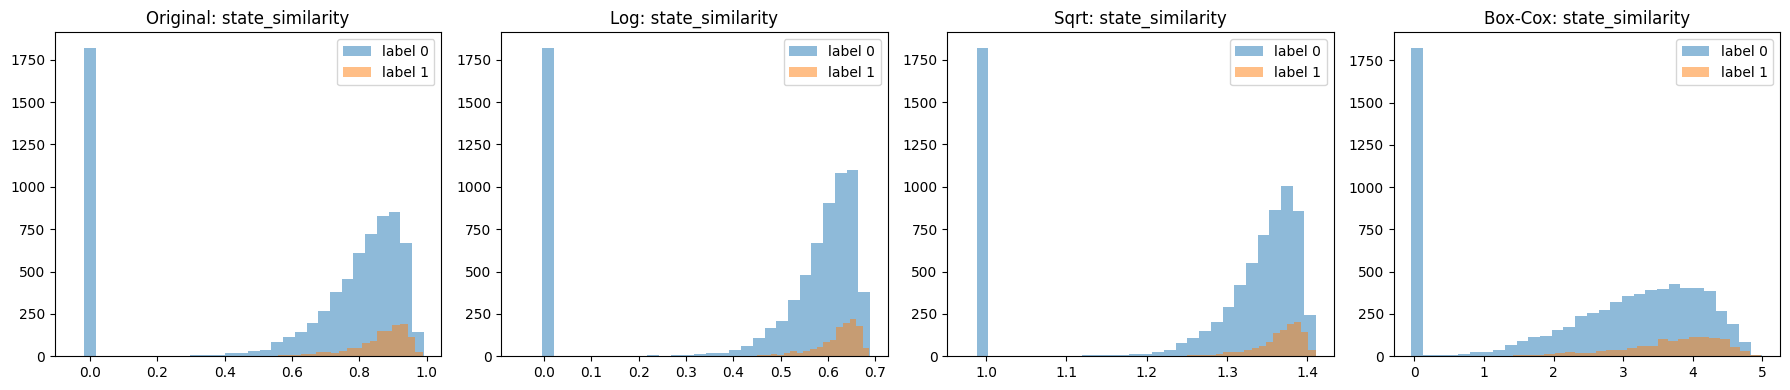

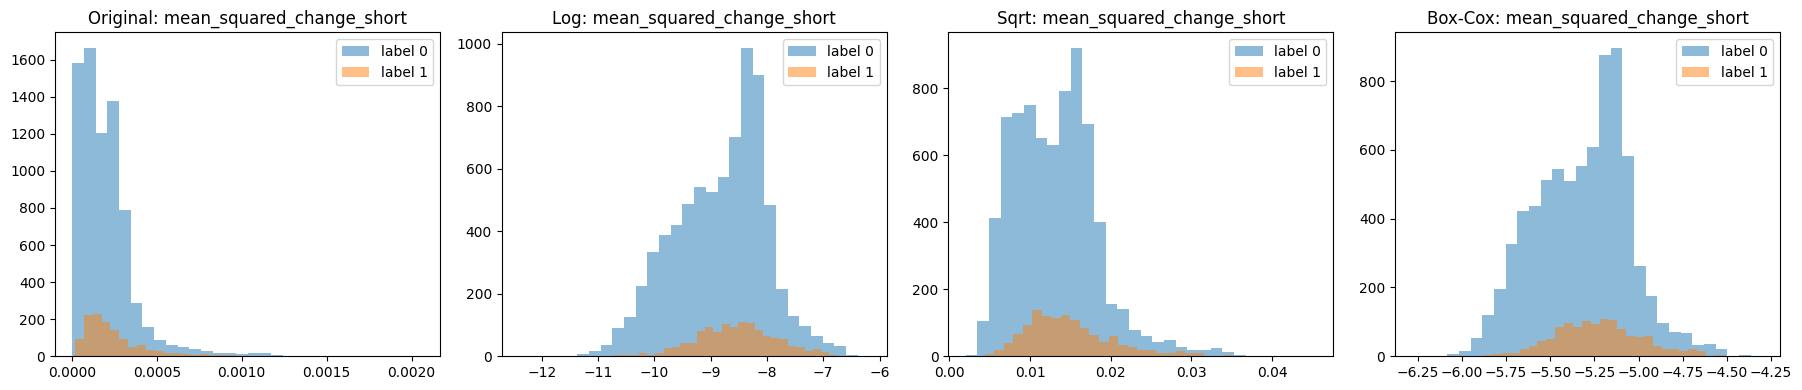

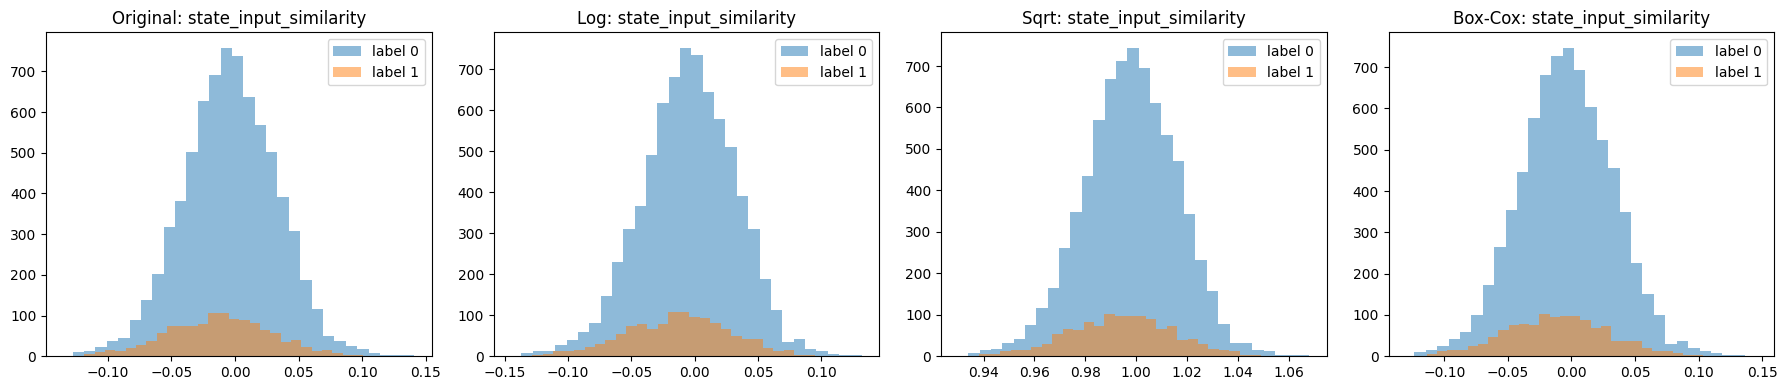

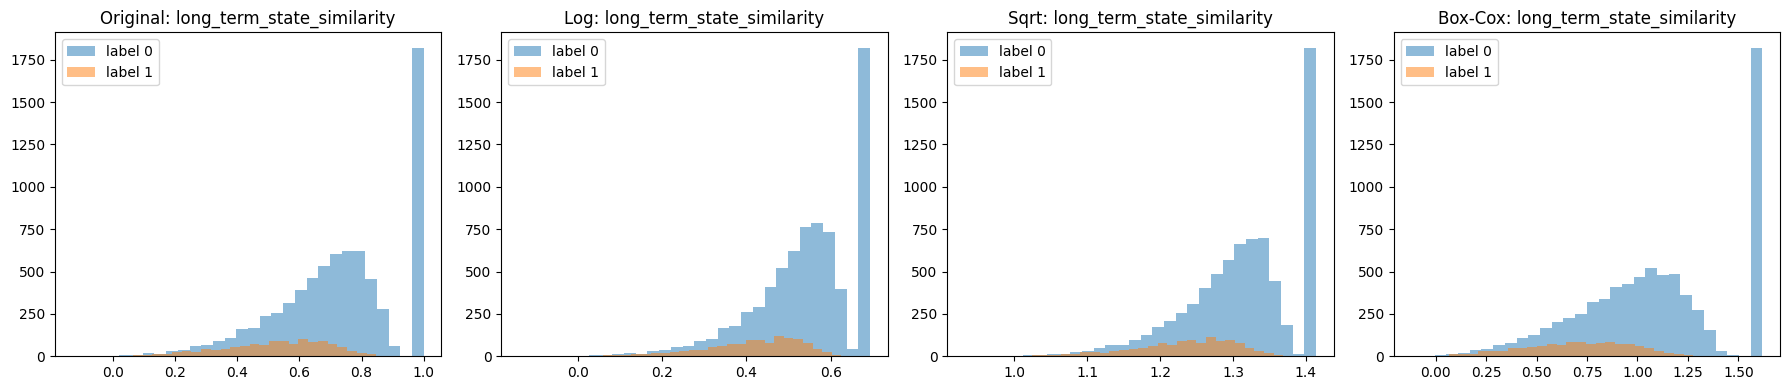

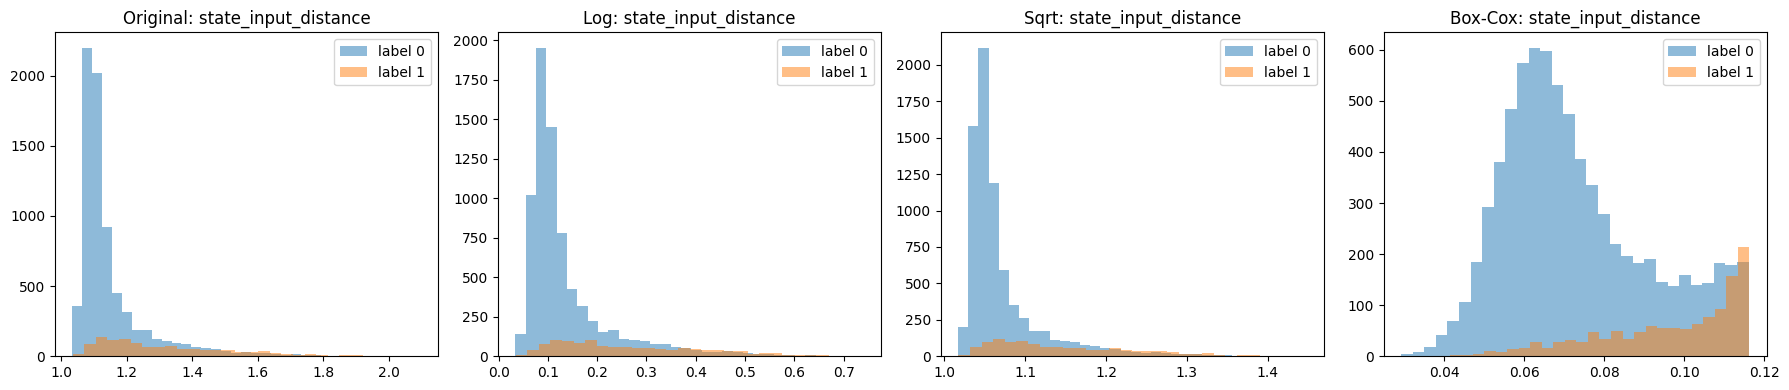

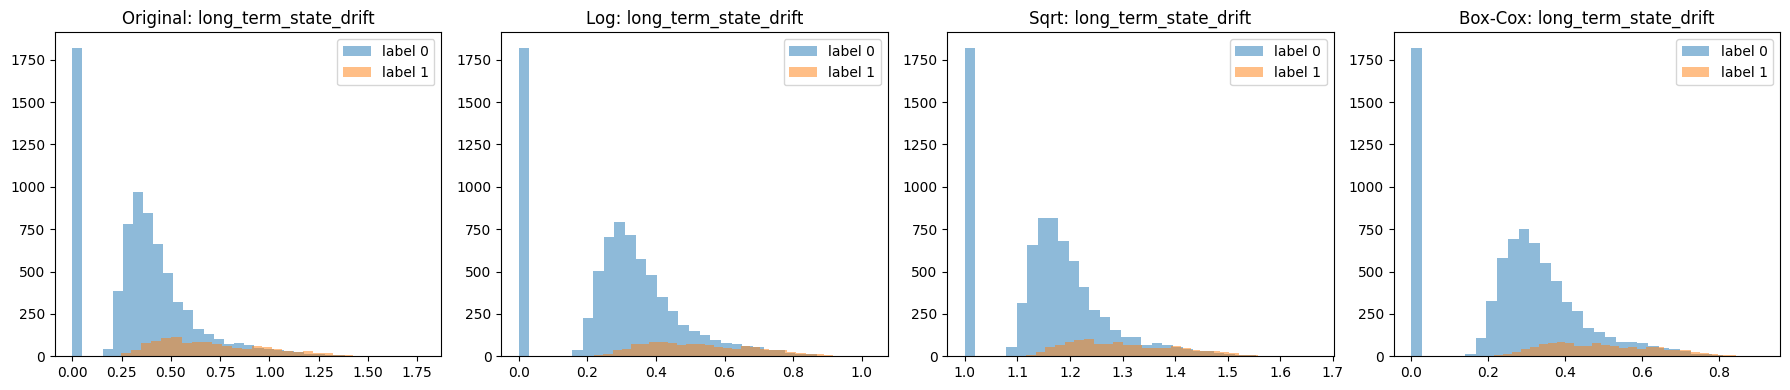

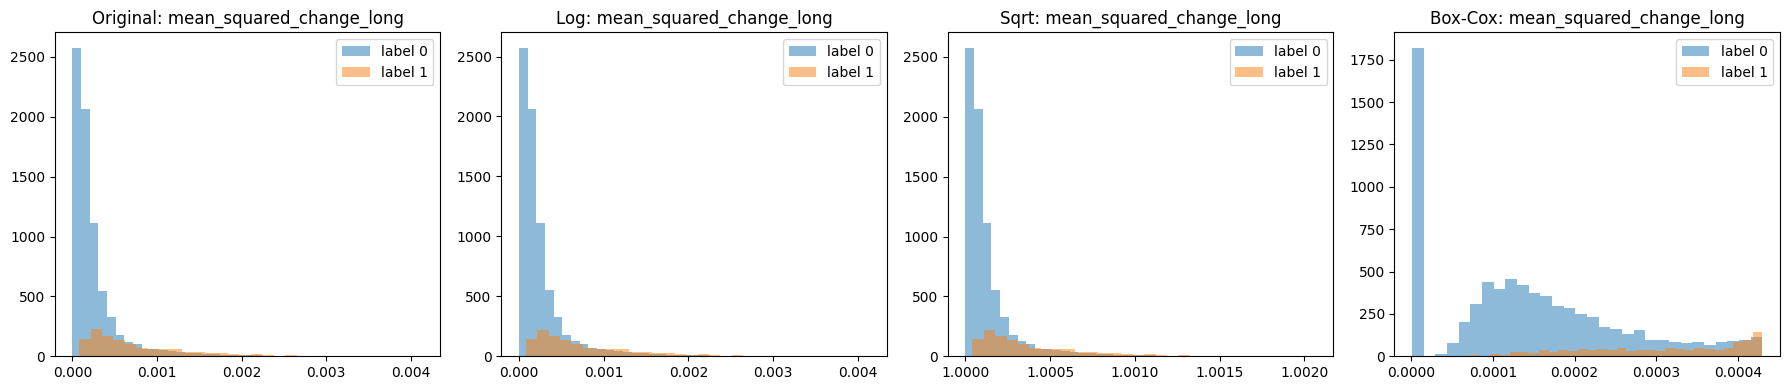

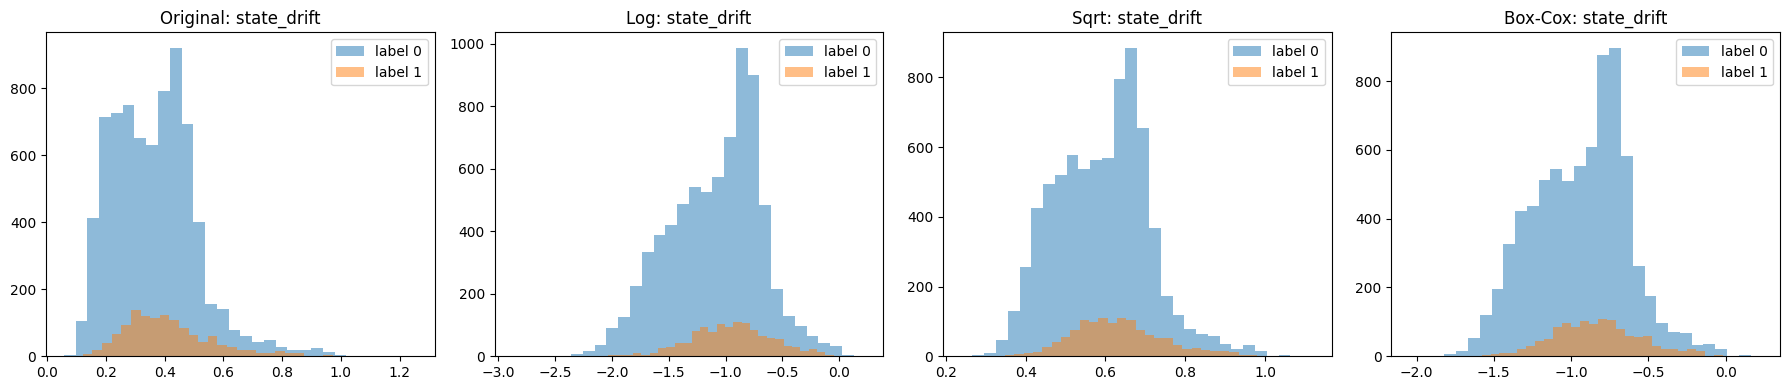

In [ ]:
for feature in feature_names:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    for lbl in df_trans["label"].unique():
        # original feature
        subset = df_trans[df_trans["label"]==lbl][feature+"_orig"]
        axes[0].hist(subset, bins=30, alpha=0.5, label=f"label {lbl}")
        # log transformation
        subset_log = df_trans[df_trans["label"]==lbl][f"{feature}_log"]
        axes[1].hist(subset_log, bins=30, alpha=0.5, label=f"label {lbl}")
        # sqrt transformation
        subset_sqrt = df_trans[df_trans["label"]==lbl][f"{feature}_sqrt"]
        axes[2].hist(subset_sqrt, bins=30, alpha=0.5, label=f"label {lbl}")
        # boxcox transformation
        subset_boxcox = df_trans[df_trans["label"]==lbl][f"{feature}_boxcox"]
        axes[3].hist(subset_boxcox, bins=30, alpha=0.5, label=f"label {lbl}")

    axes[0].set_title(f"Original: {feature}")
    axes[1].set_title(f"Log: {feature}")
    axes[2].set_title(f"Sqrt: {feature}")
    axes[3].set_title(f"Box-Cox: {feature}")

    for ax in axes:
        ax.legend()

    plt.tight_layout()
    plt.show()

In [34]:
df_trans = pd.DataFrame(all_features)
df_trans["label"] = df["label"]

In [35]:
df_trans

,state_similarity_orig,state_similarity_log,state_similarity_sqrt,state_similarity_boxcox,mean_squared_change_short_orig,mean_squared_change_short_log,mean_squared_change_short_sqrt,mean_squared_change_short_boxcox,state_input_similarity_orig,state_input_similarity_log,...,long_term_state_drift_boxcox,mean_squared_change_long_orig,mean_squared_change_long_log,mean_squared_change_long_sqrt,mean_squared_change_long_boxcox,state_drift_orig,state_drift_log,state_drift_sqrt,state_drift_boxcox,label
0,0.000000,9.999995e-07,1.000000,0.000001,0.000264,-8.240857,0.016238,-5.131145,0.025019,0.024712,...,9.999994e-07,0.000000,9.999995e-07,1.000000,9.988377e-07,0.449988,-0.798533,0.670812,-0.723460,0
1,0.789470,5.819199e-01,1.337711,2.970915,0.000116,-9.060251,0.010779,-5.407378,-0.009810,-0.009857,...,2.537358e-01,0.000116,1.171869e-04,1.000059,1.025765e-04,0.298725,-1.208231,0.546558,-1.041927,0
2,0.889950,6.365507e-01,1.374755,3.886639,0.000061,-9.699688,0.007830,-5.604017,-0.016561,-0.016699,...,2.977336e-01,0.000170,1.708260e-04,1.000085,1.409762e-04,0.216980,-1.527949,0.465811,-1.268632,0
3,0.925097,6.549771e-01,1.387479,4.251464,0.000039,-10.160675,0.006218,-5.736286,-0.007144,-0.007169,...,2.890528e-01,0.000158,1.591786e-04,1.000080,1.330402e-04,0.172313,-1.758443,0.415106,-1.421124,0
4,0.914687,6.495546e-01,1.383722,4.140858,0.000042,-10.089371,0.006443,-5.716325,0.042450,0.041574,...,3.027091e-01,0.000177,1.777508e-04,1.000089,1.455936e-04,0.178567,-1.722791,0.422572,-1.398111,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8663,0.000000,9.999995e-07,1.000000,0.000001,0.000280,-8.179637,0.016742,-5.109342,0.045808,0.044791,...,9.999994e-07,0.000000,9.999995e-07,1.000000,9.988377e-07,0.463975,-0.767924,0.681157,-0.698323,0
8664,0.726804,5.462731e-01,1.314080,2.486677,0.000264,-8.239488,0.016249,-5.130660,0.022435,0.022188,...,3.564245e-01,0.000264,2.649843e-04,1.000133,1.978171e-04,0.450296,-0.797849,0.671041,-0.722900,0
8665,0.918230,6.514034e-01,1.385002,4.178258,0.000092,-9.294589,0.009588,-5.481283,0.019304,0.019121,...,3.483107e-01,0.000249,2.502590e-04,1.000125,1.897278e-04,0.265697,-1.325399,0.515458,-1.127132,0
8666,0.893113,6.382231e-01,1.375905,3.918485,0.000225,-8.398003,0.015011,-5.186351,0.023926,0.023646,...,4.993285e-01,0.000637,6.373838e-04,1.000319,3.323530e-04,0.415985,-0.877106,0.644969,-0.787106,0


In [36]:
corr_with_label = df_trans.corr(method="pearson")["label"].drop("label")

In [ ]:
best_features_corr = []

for f in feature_names:
    candidates = {
        "orig": corr_with_label.get(f"{f}_orig", 0),
        "log": corr_with_label.get(f"{f}_log", 0),
        "sqrt": corr_with_label.get(f"{f}_sqrt", 0),
        "boxcox": corr_with_label.get(f"{f}_boxcox", 0),
    }
    best_variant = max(candidates, key=lambda k: abs(candidates[k])) # get largest absolute correlation
    best_features_corr.append(f"{f}_{best_variant}")

In [39]:
best_features_corr

['state_similarity_boxcox',
 'mean_squared_change_short_log',
 'state_input_similarity_log',
 'long_term_state_similarity_orig',
 'state_input_distance_log',
 'long_term_state_drift_orig',
 'mean_squared_change_long_boxcox',
 'state_drift_log']

In [ ]:
best_features = []
feature_scores = {}

model = RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1)
for f in feature_names:
    candidates = {
        f"{f}_orig": all_features[f"{f}_orig"],
        f"{f}_log": all_features[f"{f}_log"],
        f"{f}_sqrt": all_features[f"{f}_sqrt"],
        f"{f}_boxcox": all_features[f"{f}_boxcox"]
    }

    best_score = -np.inf
    best_version = None

    for name, feat in candidates.items():
        X_temp = np.array(feat).reshape(-1, 1)
        score = cross_val_score(model,X_temp,df["label"],cv=5,scoring="f1").mean()

        if score > best_score:
            best_score = score
            best_version = name

    best_features.append(best_version)
    feature_scores[f] = {"best_version": best_version,"best_score": best_score}

In [41]:
best_features

['state_similarity_log',
 'mean_squared_change_short_boxcox',
 'state_input_similarity_sqrt',
 'long_term_state_similarity_sqrt',
 'state_input_distance_sqrt',
 'long_term_state_drift_sqrt',
 'mean_squared_change_long_sqrt',
 'state_drift_log']

In [ ]:
X = df_trans[best_features]
y = df_trans["label"]

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)
importances = model.feature_importances_
# get sorted feature importances
feature_importance = sorted(zip(X.columns, importances), key=lambda x: x[1],reverse=True) 

for f, imp in feature_importance:
    print(f"{f}: {imp}")

long_term_state_drift_sqrt: 0.1688
mean_squared_change_long_sqrt: 0.1353
state_input_distance_sqrt: 0.1329
long_term_state_similarity_sqrt: 0.1285
state_similarity_log: 0.1270
state_drift_log: 0.1085
mean_squared_change_short_boxcox: 0.1076
state_input_similarity_sqrt: 0.0915


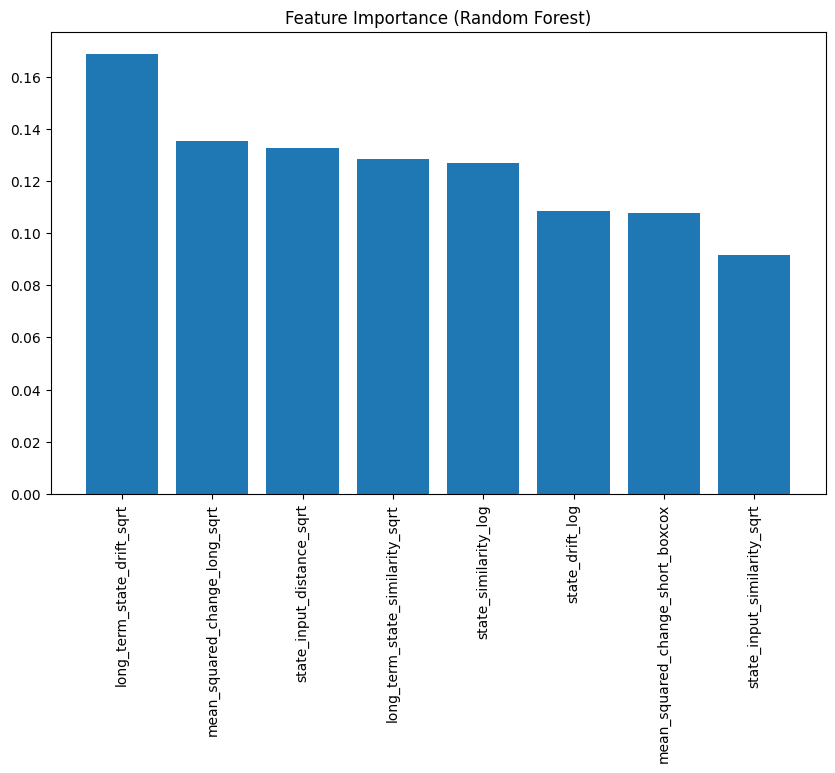

In [43]:
names = [f for f, _ in feature_importance]
values = [imp for _, imp in feature_importance]

plt.figure(figsize=(10, 6))
plt.bar(names, values)
plt.xticks(rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [44]:
df_trans

,state_similarity_orig,state_similarity_log,state_similarity_sqrt,state_similarity_boxcox,mean_squared_change_short_orig,mean_squared_change_short_log,mean_squared_change_short_sqrt,mean_squared_change_short_boxcox,state_input_similarity_orig,state_input_similarity_log,...,long_term_state_drift_boxcox,mean_squared_change_long_orig,mean_squared_change_long_log,mean_squared_change_long_sqrt,mean_squared_change_long_boxcox,state_drift_orig,state_drift_log,state_drift_sqrt,state_drift_boxcox,label
0,0.000000,9.999995e-07,1.000000,0.000001,0.000264,-8.240857,0.016238,-5.131145,0.025019,0.024712,...,9.999994e-07,0.000000,9.999995e-07,1.000000,9.988377e-07,0.449988,-0.798533,0.670812,-0.723460,0
1,0.789470,5.819199e-01,1.337711,2.970915,0.000116,-9.060251,0.010779,-5.407378,-0.009810,-0.009857,...,2.537358e-01,0.000116,1.171869e-04,1.000059,1.025765e-04,0.298725,-1.208231,0.546558,-1.041927,0
2,0.889950,6.365507e-01,1.374755,3.886639,0.000061,-9.699688,0.007830,-5.604017,-0.016561,-0.016699,...,2.977336e-01,0.000170,1.708260e-04,1.000085,1.409762e-04,0.216980,-1.527949,0.465811,-1.268632,0
3,0.925097,6.549771e-01,1.387479,4.251464,0.000039,-10.160675,0.006218,-5.736286,-0.007144,-0.007169,...,2.890528e-01,0.000158,1.591786e-04,1.000080,1.330402e-04,0.172313,-1.758443,0.415106,-1.421124,0
4,0.914687,6.495546e-01,1.383722,4.140858,0.000042,-10.089371,0.006443,-5.716325,0.042450,0.041574,...,3.027091e-01,0.000177,1.777508e-04,1.000089,1.455936e-04,0.178567,-1.722791,0.422572,-1.398111,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8663,0.000000,9.999995e-07,1.000000,0.000001,0.000280,-8.179637,0.016742,-5.109342,0.045808,0.044791,...,9.999994e-07,0.000000,9.999995e-07,1.000000,9.988377e-07,0.463975,-0.767924,0.681157,-0.698323,0
8664,0.726804,5.462731e-01,1.314080,2.486677,0.000264,-8.239488,0.016249,-5.130660,0.022435,0.022188,...,3.564245e-01,0.000264,2.649843e-04,1.000133,1.978171e-04,0.450296,-0.797849,0.671041,-0.722900,0
8665,0.918230,6.514034e-01,1.385002,4.178258,0.000092,-9.294589,0.009588,-5.481283,0.019304,0.019121,...,3.483107e-01,0.000249,2.502590e-04,1.000125,1.897278e-04,0.265697,-1.325399,0.515458,-1.127132,0
8666,0.893113,6.382231e-01,1.375905,3.918485,0.000225,-8.398003,0.015011,-5.186351,0.023926,0.023646,...,4.993285e-01,0.000637,6.373838e-04,1.000319,3.323530e-04,0.415985,-0.877106,0.644969,-0.787106,0


# apply transformation on test and val

In [ ]:
def apply_selected_transformations(df, selected_features):
    transformed = {}

    for feature in selected_features:
        transform = feature.split("_")[-1]
        base_feature = "_".join(feature.split("_")[:-1])
        x = df[base_feature].copy()
        if transform == "orig":
            transformed[base_feature] = x

        else:
            x = x + 1 + 1e-6
            if transform == "log":
                transformed[feature] = np.log(x)
            elif transform == "sqrt":
                transformed[feature] = np.sqrt(x)
            elif transform == "boxcox":
                transformed[feature], _ = stats.boxcox(x)
            else:
                raise ValueError(f"Unknown transformation: {transform}")

    return pd.DataFrame(transformed)

In [ ]:
selected_features = [
    'long_term_state_drift_sqrt', 
    'mean_squared_change_long_sqrt', 
    'state_input_distance_sqrt', 
    'long_term_state_similarity_sqrt',
    'state_similarity_log',
    'conv_id_orig',
    'turn_id_orig'
]

In [85]:
df1=apply_selected_transformations(df_all, selected_features)
df2=apply_selected_transformations(df_validation, selected_features)
df3=apply_selected_transformations(df_test, selected_features)

In [86]:
final_df_trans = pd.concat([df1, df2, df3], ignore_index=True)

In [87]:
final_df_trans

,long_term_state_drift_sqrt,mean_squared_change_long_sqrt,state_input_distance_sqrt,long_term_state_similarity_sqrt,state_similarity_log,conv_id,turn_id
0,1.000000,1.000000,1.444391,1.414214,9.999995e-07,0,0
1,1.139617,1.000059,1.452137,1.337711,5.819199e-01,0,1
2,1.166689,1.000085,1.450848,1.296392,6.365507e-01,0,2
3,1.161274,1.000080,1.444922,1.296767,6.549771e-01,0,3
4,1.169809,1.000089,1.440488,1.287193,6.495546e-01,0,4
...,...,...,...,...,...,...,...
14379,1.000000,1.000000,1.450225,1.414214,9.999995e-07,3028,0
14380,1.211997,1.000144,1.447433,1.193868,3.543973e-01,3028,1
14381,1.300271,1.000311,1.483147,1.137600,5.733441e-01,3028,2
14382,1.291883,1.000292,1.470261,1.087260,6.179839e-01,3028,3


In [94]:
df_final=pd.merge(df_vectors, final_df_trans, on=["conv_id","turn_id"], how='inner')

In [95]:
df_final

,0,1,2,3,4,5,6,7,8,9,...,1534,1535,conv_id,turn_id,y,long_term_state_drift_sqrt,mean_squared_change_long_sqrt,state_input_distance_sqrt,long_term_state_similarity_sqrt,state_similarity_log
0,0.022156,0.009600,-0.005651,0.037142,0.026982,0.014868,-0.013620,-0.011513,0.020963,-0.005187,...,-0.038129,-0.020168,0.0,0.0,0,1.000000,1.000000,1.444391,1.414214,9.999995e-07
1,0.033551,0.014626,-0.013005,0.029625,0.038335,-0.000664,-0.020039,-0.016444,0.017359,0.001949,...,0.001111,0.016277,0.0,1.0,0,1.139617,1.000059,1.452137,1.337711,5.819199e-01
2,0.028587,0.021823,-0.007307,0.023240,0.034987,-0.015518,-0.027399,-0.020127,0.009395,-0.001386,...,0.015822,0.000744,0.0,2.0,0,1.166689,1.000085,1.450848,1.296392,6.365507e-01
3,0.014920,0.008290,-0.004189,0.028177,0.026437,-0.005988,-0.020008,-0.018204,0.015614,0.006017,...,0.004717,-0.005025,0.0,3.0,0,1.161274,1.000080,1.444922,1.296767,6.549771e-01
4,0.018797,0.009575,0.000537,0.024246,0.037969,-0.012389,-0.027038,-0.023365,0.010820,0.000679,...,-0.010719,-0.002960,0.0,4.0,0,1.169809,1.000089,1.440488,1.287193,6.495546e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14379,-0.039515,-0.010074,0.023661,0.012855,0.003421,-0.014791,-0.001751,-0.013007,-0.003218,0.023564,...,0.032729,0.041474,3036.0,0.0,0,1.000000,1.000000,1.454085,1.414214,9.999995e-07
14380,-0.025135,-0.037671,0.049991,0.015364,0.017914,-0.003555,-0.016524,-0.040135,0.000613,0.039743,...,-0.042925,0.051836,3036.0,1.0,0,1.261505,1.000228,1.521309,1.315456,5.483675e-01
14381,-0.045876,-0.045405,0.060885,0.009341,0.021263,-0.006970,-0.020927,-0.049787,-0.003796,0.040816,...,0.044166,0.005600,3036.0,2.0,0,1.350359,1.000442,1.569649,1.282483,6.535557e-01
14382,-0.025517,-0.023269,0.039099,-0.018240,0.013294,-0.007832,-0.033553,-0.047526,-0.006112,0.039862,...,-0.021671,0.021756,3036.0,3.0,0,1.250940,1.000208,1.503998,1.282856,6.065169e-01


In [97]:
df_final.to_csv("./ssm_final_features_new_data_new_label.csv", index=False)

In [96]:
"y" in df_final.columns

True